# E4 — ISIC 2017 UNet2D Decision-Threshold Selection (10 seeds)

**Research question.** The locked model is `classical + attention_gate` at `lr = 3e-4` (see E2). At inference, its sigmoid output map is binarised at a decision threshold τ. This experiment evaluates whether replacing the default **τ = 0.5** with a validation-tuned threshold **τ\*** yields a deployable improvement.

**Experimental design.** Ten independent seeds (100–109) are trained, each using the `classical + attention_gate` configuration. At every epoch, a grid search over τ is performed on the ISIC-2017 *validation* set, recording: the best Dice under τ\* (`val_best_dice_at_threshold`), the argmax threshold (`val_optimal_threshold`), and the in-sample gain over the fixed-τ = 0.5 baseline. Each run is summarised at its **best swept epoch** — the epoch maximising `val_best_dice_at_threshold`, corresponding to the deployment checkpoint — and two sequential questions are posed:

1. **Q1 — Is the gain real?** Paired comparison of swept-Dice versus 0.5-Dice at the same epoch.
2. **Q2 — Is τ\* deployable?** Threshold-stability diagnostics across seeds and across epochs within a run.

**Data sources.** `E4-isic2017-unet2d-thres-sweep.db` (seeds 100–105) and `…-part2.db` (seeds 106–109) — 10 `FINISHED` runs in total.

> **Scope note.** τ\* is selected on the same 150 validation images against which it is scored. A positive in-sample gain is therefore expected by construction; the stability diagnostics in Q2 constitute the operative test of deployability.

## Executive summary

- Paired comparison across 10 seeds: Δ = swept − fixed-0.5, evaluated at the same model weights and best-swept epoch.
- Primary test: Wilcoxon signed-rank.
- Confidence interval: BCa bootstrap 95 % (10 000 resamples, seed = 42).
- d_z: Cohen's paired effect size.

| Metric | Swept τ* | Fixed τ = 0.5 | Δ (swept−fixed) | 95 % BCa CI | Wilcoxon p | d_z | Verdict |
|---|---|---|---|---|---|---|---|
| **In-sample Dice gain** — *primary* | 0.8503 | 0.8300 | **+0.0203** | [+0.0145, +0.0262] | **0.0020** | +2.48 | Gain confirmed — in-sample only |

**Stability (Q2 — operative test).**

| Axis | What is measured | Epoch(s) | Median | SD | \|median − 0.5\| | Verdict |
|---|---|---|---|---|---|---|
| **τ\* across seeds** | τ\* at each seed's best-swept epoch — 10 values, one per deployment checkpoint | best-swept epoch (one per seed) | **0.46** | 0.106 | **0.04** | **Fail** — displacement from 0.5 is less than one SD; median is statistically indistinguishable from the incumbent |
| **τ\* epoch stability** | within-run SD of τ\* per seed, averaged over 10 seeds; global range [0.06, 0.81] | epochs 50 → end (post-warm-up tail) | — | mean **0.137** | — | **Fail** — τ\* co-varies with validation noise rather than reflecting a stable decision boundary |

**Decision:** retain the fixed decision threshold **τ = 0.5**.

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

PROJECT_ROOT = Path('/teamspace/studios/this_studio/repos/SkiNet')
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from IPython.display import display

from SkiNet.Utils.analysis.plotting import (
    set_paper_style,
    plot_threshold_slopegraph,
    plot_threshold_forest,
    plot_tau_across_seeds,
    plot_tau_trajectories,
)
from SkiNet.Utils.analysis.reporting import show_gain_table
from SkiNet.Utils.analysis.threshold_sweep import (
    load_threshold_sweep, epoch_trajectories,
    paired_gain_stats, threshold_stability,
    TAU_KEY,
)

# ── Configuration — every tunable argument lives in this cell ────────────────────
FIG_DIR     = PROJECT_ROOT / 'analysis_results'
DB1 = PROJECT_ROOT / 'mlruns' / 'E4-isic2017-unet2d-thres-sweep.db'        # seeds 100-105
DB2 = PROJECT_ROOT / 'mlruns' / 'E4-isic2017-unet2d-thres-sweep-part2.db'  # seeds 106-109

PART_SPLIT  = 105       # seeds <= 105 -> part P1, else P2 (for sanity reporting only)
WARMUP      = 50        # epochs dropped before measuring tau* wander (pre-convergence ROC is degenerate)
ALPHA       = 0.05
DEFAULT_TAU = 0.5       # the fixed threshold we are testing against
N_BOOT      = 10_000    # bootstrap samples for CIs
RNG_SEED    = 42        # bootstrap seed; int so re-running any cell reproduces identical CIs

# Palette — swept (tuned) vs fixed-0.5, kept consistent with the house red/blue.
C_SWEPT, C_FIXED, C_TAU = '#d1495b', '#30638e', '#3a5a40'
PALETTE = {'swept': C_SWEPT, 'fixed': C_FIXED}

# Metric specs — same pattern as E2
_DICE_COL    = 'val_dice_at_threshold'
SLOPE_METRICS = [(_DICE_COL, 'Validation Dice (best swept epoch)\nin-sample gain — NOT a deployment claim')]
FOREST_SPECS  = [('In-sample Dice gain (swept − 0.5)', 'in_sample_dice_gain', False)]

set_paper_style(context='notebook')
pd.set_option('display.width', 240)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Data

`load_threshold_sweep` collapses each run to **one row at its best swept epoch** — the epoch maximising `val_best_dice_at_threshold`, which corresponds to the deployment checkpoint. Columns:

- **`val_best_dice_at_threshold`** — Dice at the per-epoch argmax threshold τ\* (in-sample optimum).
- **`val_dice`** — Dice of the *same* model and epoch evaluated at the fixed τ = 0.5.
- **`val_dice_gain`** — `val_best_dice_at_threshold − val_dice`; the paired in-sample improvement attributable to threshold tuning.
- **`val_optimal_threshold`** — the selected threshold τ\* at that epoch.
- **`val_tau_wander_sd` / `val_tau_min` / `val_tau_max`** — standard deviation and range of τ\* over the post-warm-up epoch tail (within-run instability).
- **`val_iou` / `gen_gap` / `samples_per_sec`** — supplementary metrics recorded at the same epoch.

In [2]:
per_seed = load_threshold_sweep(DB1, DB2, part_split=PART_SPLIT, warmup=WARMUP)
SEEDS, N = per_seed['seed'].tolist(), len(per_seed)
print(f'Loaded {N} runs | seeds: {SEEDS}')
per_seed

Loaded 10 runs | seeds: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]


,seed,part,best_ep,val_best_dice_at_threshold,val_dice,val_dice_gain,val_optimal_threshold,val_tau_wander_sd,val_tau_min,val_tau_max,val_iou,gen_gap,samples_per_sec,n_epochs
0,100,P1,133,0.8641,0.8346,0.0295,0.4100,0.1247,0.0600,0.6800,0.7254,0.0697,103.1489,200
1,101,P1,172,0.8558,0.8228,0.0330,0.5600,0.1468,0.0800,0.6800,0.7079,0.0894,102.8123,200
2,102,P1,154,0.8680,0.8390,0.0289,0.5800,0.1438,0.0600,0.6600,0.7291,0.0721,102.8735,200
3,103,P1,193,0.8651,0.8507,0.0144,0.3200,0.1424,0.0700,0.7800,0.7473,0.0766,102.9969,200
4,104,P1,172,0.8621,0.8442,0.0179,0.4800,0.1504,0.0700,0.8000,0.7372,0.0706,103.0511,200
5,105,P1,181,0.8635,0.8470,0.0165,0.4700,0.1386,0.0700,0.7300,0.7404,0.0694,103.8735,200
6,106,P2,172,0.8602,0.8438,0.0163,0.3000,0.1216,0.0600,0.6400,0.7353,0.0629,104.1282,200
7,107,P2,152,0.8530,0.8448,0.0082,0.4000,0.1370,0.0900,0.7900,0.7372,0.0704,104.1130,200
8,108,P2,193,0.8601,0.8467,0.0134,0.4500,0.1373,0.0700,0.8100,0.7398,0.0749,104.2626,200
9,109,P2,132,0.8598,0.8348,0.0250,0.6200,0.1288,0.0700,0.6900,0.7232,0.0751,103.7278,200


## 2. Statistical methods

### 2.1 Two independent questions

This experiment addresses a *calibration* question rather than an A/B model comparison. Two conditions must both be satisfied before a validation-tuned threshold is considered deployable.

| Question | What it tests | Statistic |
|---|---|---|
| **Q1 — Is the gain real?** | Does τ\* improve Dice over τ = 0.5 on the validation set? | Wilcoxon signed-rank + BCa bootstrap CI + d_z on the 10 paired (swept, 0.5) differences |
| **Q2 — Is τ\* deployable?** | Does the selected τ\* generalise — i.e. is it stable across runs and stable within a run? | Spread of τ\* across seeds; epoch-to-epoch variation within each run |

### 2.2 Q1 — paired in-sample gain (`paired_gain_stats`)

Within each seed, the swept and fixed-0.5 scores are obtained from **identical weights at the same epoch**, so the only source of variation is τ. The 10 paired differences Δᵢ = sweptᵢ − dice_05ᵢ eliminate both seed-to-seed and convergence-related variability.

- **Wilcoxon signed-rank** — non-parametric, rank-based, robust to outlier seeds; H₀: median Δ = 0. At n = 10 the minimum achievable two-tailed p is 2 / 2¹⁰ = **0.00195**, attained only when all 10 differences share a common sign.
- **BCa bootstrap 95 % CI on mean(Δ)** — 10 000 resamples, seed = 42; consistent with the E2 protocol. An interval excluding 0 establishes the sign of the mean effect.
- **Cohen's d_z** $= \bar\Delta\,/\,\mathrm{SD}(\Delta,\ \mathrm{ddof}=1)$ — the paired signal-to-noise ratio. Reference scale (Cohen 1988): 0.2 small · 0.5 medium · 0.8 large. Reported as a descriptive quantity at n = 10.

### 2.3 Q2 — threshold stability (`threshold_stability`)

A calibration gain is deployable **only if the threshold that produced it is stable**. Two independent failure modes are assessed; either one alone is sufficient to disqualify a tuned threshold.

#### Failure mode A — τ\* does not agree across seeds

**What is measured.** Each run is reduced to a single row at its **best-swept epoch** — the epoch maximising `val_best_dice_at_threshold`, i.e. the deployment checkpoint. At that epoch, τ\* (the argmax threshold) is recorded. This yields **10 values, one per seed**, representing the threshold each independently trained model instance would recommend for deployment.

The stability summary reports the median, mean, and standard deviation of those 10 values, together with `tau_dist_from_half` = |median(τ\*) − 0.5|.

**Interpretation.** If the 10 seeds recommend thresholds scattered around 0.5 with no consistent direction, there is no systematic miscalibration that the architecture consistently exhibits. The per-seed gains then reflect each run adapting to its own validation sample rather than a shared property of the model.

**Failure criterion.** `tau_dist_from_half < tau_sd` — the median lies within one standard deviation of 0.5 and is therefore statistically indistinguishable from the incumbent.

#### Failure mode B — τ\* does not converge within a run

**What is measured.** For each seed, τ\* is recorded at every epoch from warm-up (epoch `WARMUP = 50`) to the end of training. The standard deviation of those per-epoch τ\* values within that run is `tau_wander_sd`; the mean across all 10 runs is `mean_wander_sd`. The global minimum and maximum of τ\* across all seeds and all post-warm-up epochs define the range `[tau_global_min, tau_global_max]`.

**Interpretation.** A well-calibrated threshold should reflect a fixed property of the model's decision boundary. Once the model has converged in Dice, τ\* should also stabilise. A high within-run standard deviation indicates that τ\* is tracking the sampling variability of the 150-image validation set rather than a structural property of the learned weights.

**Failure criterion.** `mean_wander_sd > 0.05` — τ\* varies by more than 5 percentage points on average after the warm-up period.

> **Independence of failure modes.** The two failure modes are orthogonal. Failure mode A indicates that different model instances would require different deployment thresholds — there is no shared miscalibration to correct. Failure mode B indicates that even a single instance cannot produce a reliable threshold estimate. Either condition alone is sufficient grounds to reject a tuned threshold.

**Deployment rule.** A tuned threshold is recommended only when (Q1 is significant) **and** (`tau_dist_from_half` substantially exceeds `tau_sd`) **and** (`mean_wander_sd` < 0.05). Failure on either stability criterion entails retaining τ = 0.5.

## 3. Results

### 3.1 Q1 — In-sample gain: is the improvement over τ = 0.5 statistically significant?

In [3]:
gain = paired_gain_stats(per_seed, n_resamples=N_BOOT, random_state=RNG_SEED)
show_gain_table(per_seed, gain, alpha=ALPHA)

,val_best_dice_at_threshold,val_dice (τ=0.5),Δ (swept−0.5),95% BCa CI,wilcoxon_p,sig,d_z,wins
in_sample_dice_gain,0.8612,0.8408,+0.0203,"[+0.0158, +0.0255]",0.0020,✓,2.4800,10/10


  per-seed Δ : [0.0295, 0.033, 0.0289, 0.0144, 0.0179, 0.0165, 0.0163, 0.0082, 0.0134, 0.025]
  → REJECT H0 (gain ≠ 0) — in-sample only


### 3.2 Q2 — Threshold stability: is τ\* consistent enough to deploy?

In [4]:
stab = threshold_stability(per_seed)


Across seeds (does τ* agree run-to-run?)
  median τ*           : 0.460
  mean τ*             : 0.459
  SD of τ* (seeds)    : 0.106
  |median − 0.5|      : 0.040

Within a run, across epochs (does τ* converge?)
  mean within-run SD  : 0.137
  global τ* range     : [0.06, 0.81]

Verdict on stability:
  median τ* within 1 SD of 0.5 ? True  → no systematic miscalibration
  τ* wanders within a run ?      True  → τ* tracks val noise, not converged


## 4. Figures

- **Fig 1 — paired slopegraph.** One line per seed from τ = 0.5 to the swept τ\* Dice. All 10 lines rise, reflecting the universal in-sample gain
- **Fig 2 — forest plot.** Point estimate = mean Δ; interval = BCa 95 % CI (§2.2). The interval excludes 0, confirming the in-sample gain; axis labels explicitly indicate the in-sample scope.
- **Fig 3 — τ\* across seeds.** Selected threshold per seed relative to the τ = 0.5 reference. Values are distributed on both sides of 0.5 with no consistent directional offset.
- **Fig 4 — τ\* epoch trajectories.** Within-run τ\* over the course of training (post-warm-up). τ\* does not converge, exhibiting large-amplitude fluctuations across nearly the entire unit interval in every seed.

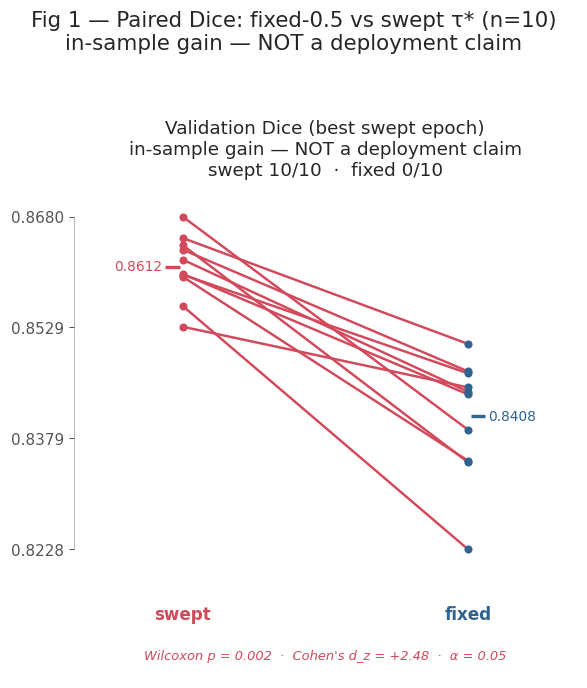

In [9]:
plot_threshold_slopegraph(
    per_seed, gain, SLOPE_METRICS,
    palette=PALETTE, seeds=SEEDS, alpha=ALPHA,
    title=f'Fig 1 — Paired Dice: fixed-0.5 vs swept τ* (n={N})\nin-sample gain — NOT a deployment claim',
    save_path=FIG_DIR / 'E4_NEW_fig1_paired_slopegraph.png',
);

/teamspace/studios/this_studio/repos/SkiNet/SkiNet/Utils/analysis/plotting.py:806: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


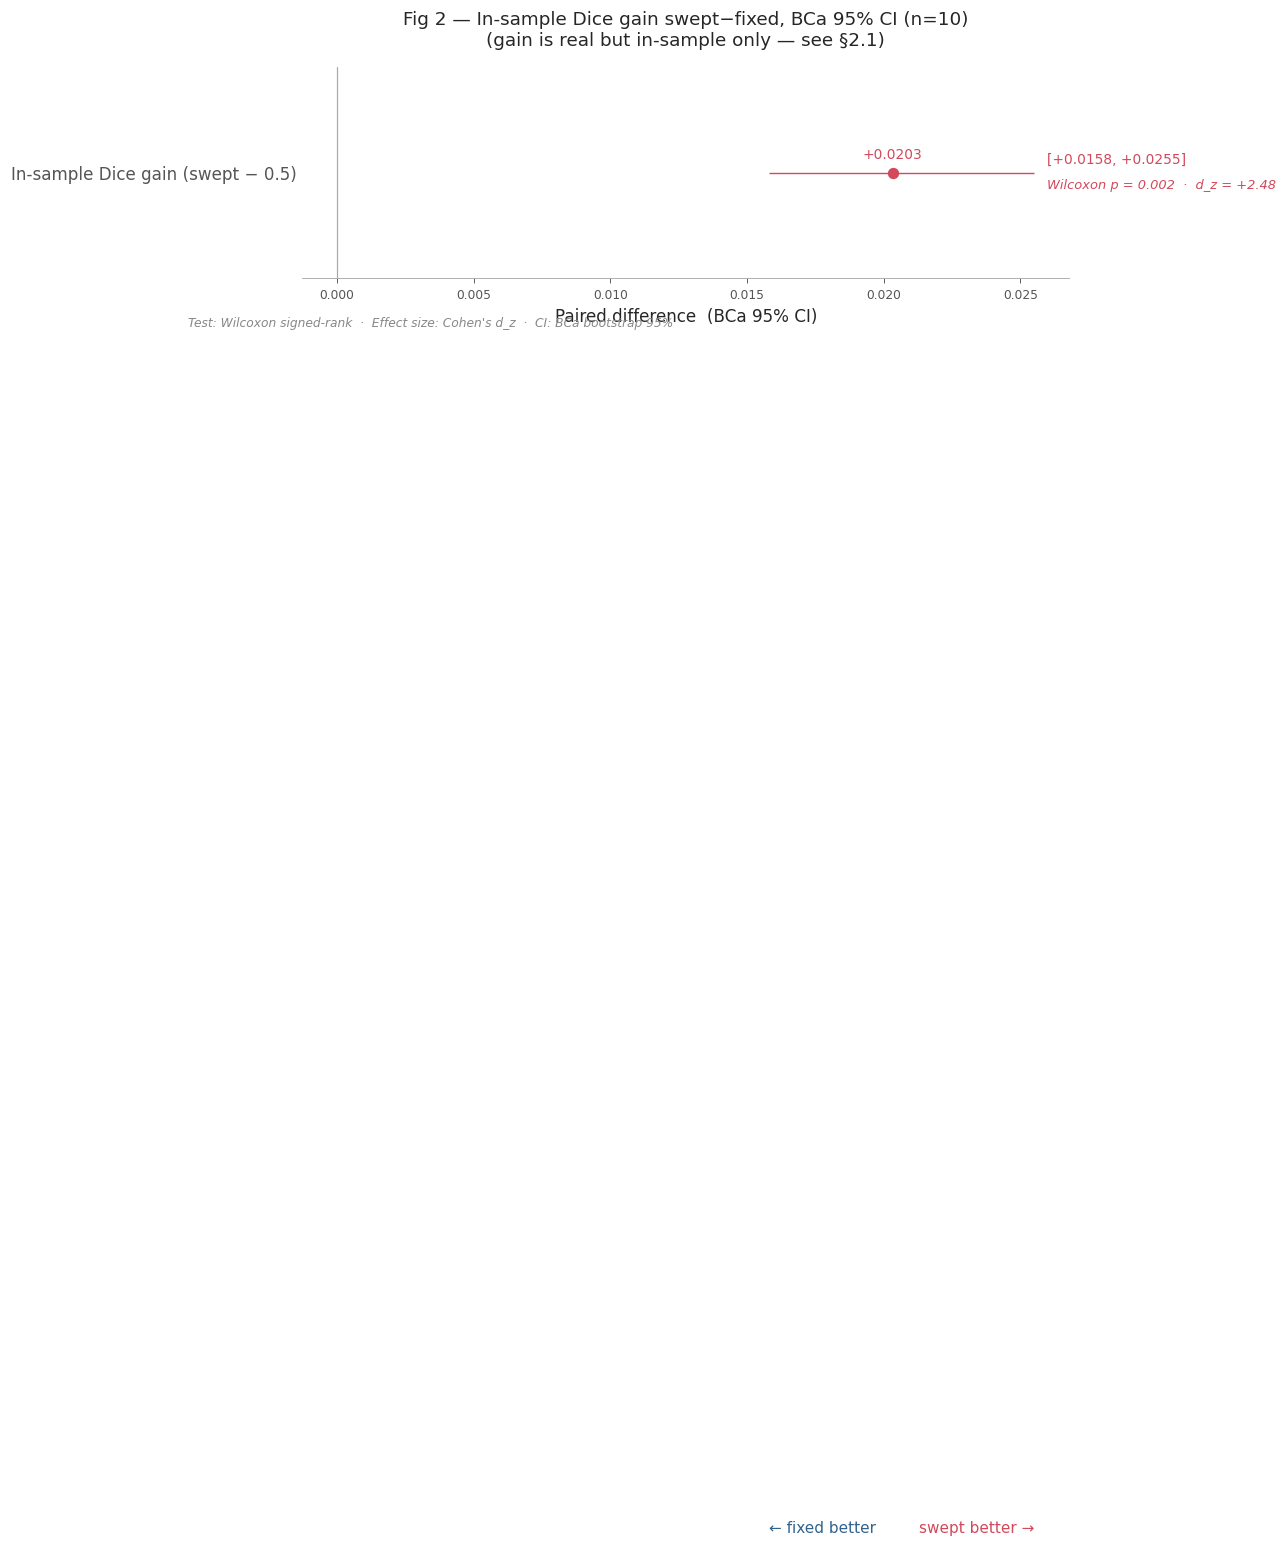

In [6]:
plot_threshold_forest(
    gain, FOREST_SPECS,
    palette=PALETTE, n=N, alpha=ALPHA,
    title=(
        f'Fig 2 — In-sample Dice gain swept−fixed, BCa 95% CI (n={N})\n'
        f'(gain is real but in-sample only — see §2.1)'
    ),
    save_path=FIG_DIR / 'E4_NEW_fig2_forest_gain.png',
);

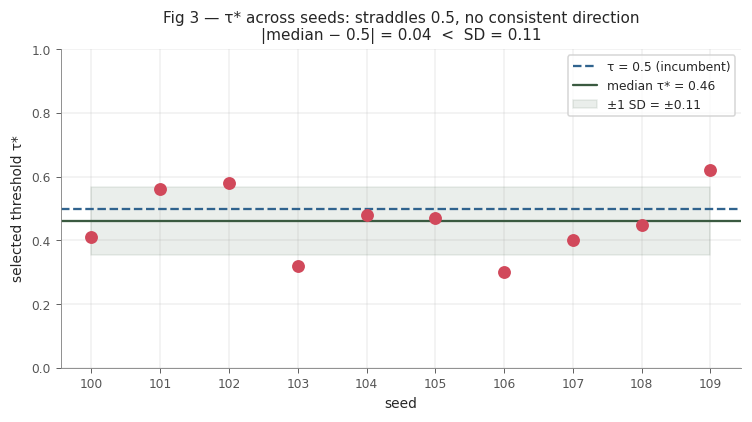

In [7]:
plot_tau_across_seeds(
    per_seed, stab,
    default_tau=DEFAULT_TAU,
    c_fixed=C_FIXED, c_swept=C_SWEPT, c_tau=C_TAU,
    save_path=FIG_DIR / 'E4_NEW_fig3_tau_across_seeds.png',
);

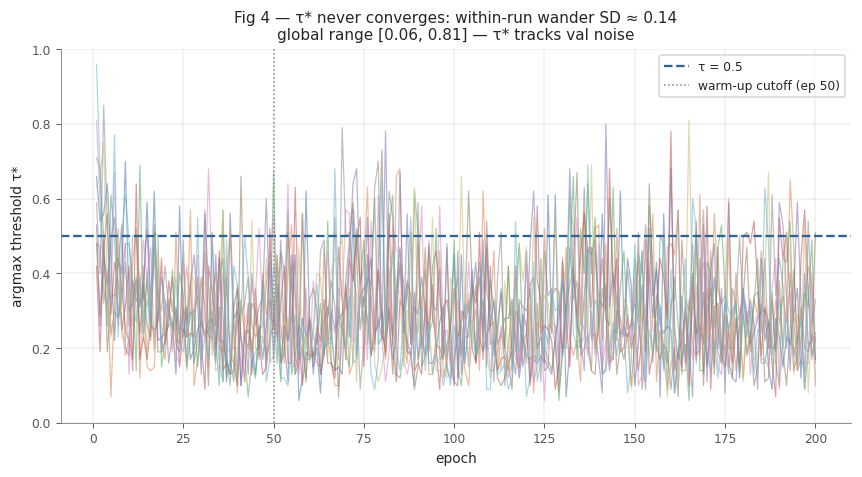

In [8]:
traj = epoch_trajectories(DB1, DB2, keys=(TAU_KEY,), part_split=PART_SPLIT)
plot_tau_trajectories(
    traj, stab,
    warmup=WARMUP, default_tau=DEFAULT_TAU, tau_key=TAU_KEY,
    c_fixed=C_FIXED,
    save_path=FIG_DIR / 'E4_NEW_fig4_tau_trajectories.png',
);

## 5. Decision

> **The fixed decision threshold τ = 0.5 is retained. Deployment of a validation-tuned per-run τ\* is not supported by this evidence.**

| Priority | Criterion | Result | Status (n = 10) |
|---|---|---|---|
| 1 | **τ\* stability across seeds** *(operative)* | median 0.46, SD 0.106, \|median − 0.5\| = 0.04 | **Fail** — τ\* straddles 0.5 with no consistent directional offset; the median is statistically indistinguishable from the 0.5 base value |
| 2 | **τ\* convergence within a run** *(operative)* | wander SD ≈ 0.137, range [0.06, 0.81] | **Fail** — τ\* co-varies with validation sampling noise and does not stabilise across epochs |
| 3 | In-sample gain (swept − 0.5) | +0.0203 Dice, 10/10 seeds, p = 0.002, d_z = +2.48 | Confirmed — **in-sample only** — the gain is expected by construction of the argmax-on-evaluation-set estimator |

**Rationale.** The +2 Dice-point gain is unanimous across seeds and statistically maximal (Wilcoxon p = 0.002, the minimum achievable at n = 10), yet it is produced by selecting τ\* on the same 150 images used for scoring. Both operant stability criteria fail: the selected threshold neither *agrees across seeds* — its median is 0.04 from 0.5, well within one standard deviation — nor *converges within a run*, fluctuating across nearly the full unit interval epoch-to-epoch. The fixed threshold τ = 0.5 is therefore the correct, robust choice.

> A 5-fold CV on he 150 image val se would be an option